In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA4'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import subprocess
import json
from pathlib import Path

print("✅ Environnement prêt")

✅ Environnement prêt


C:\Users\loich\AppData\Local\Temp\ipykernel_31824\1543739706.py:44: UserWarning: Glyph 128012 (\N{SNAIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Temp\ipykernel_31824\1543739706.py:44: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128012 (\N{SNAIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


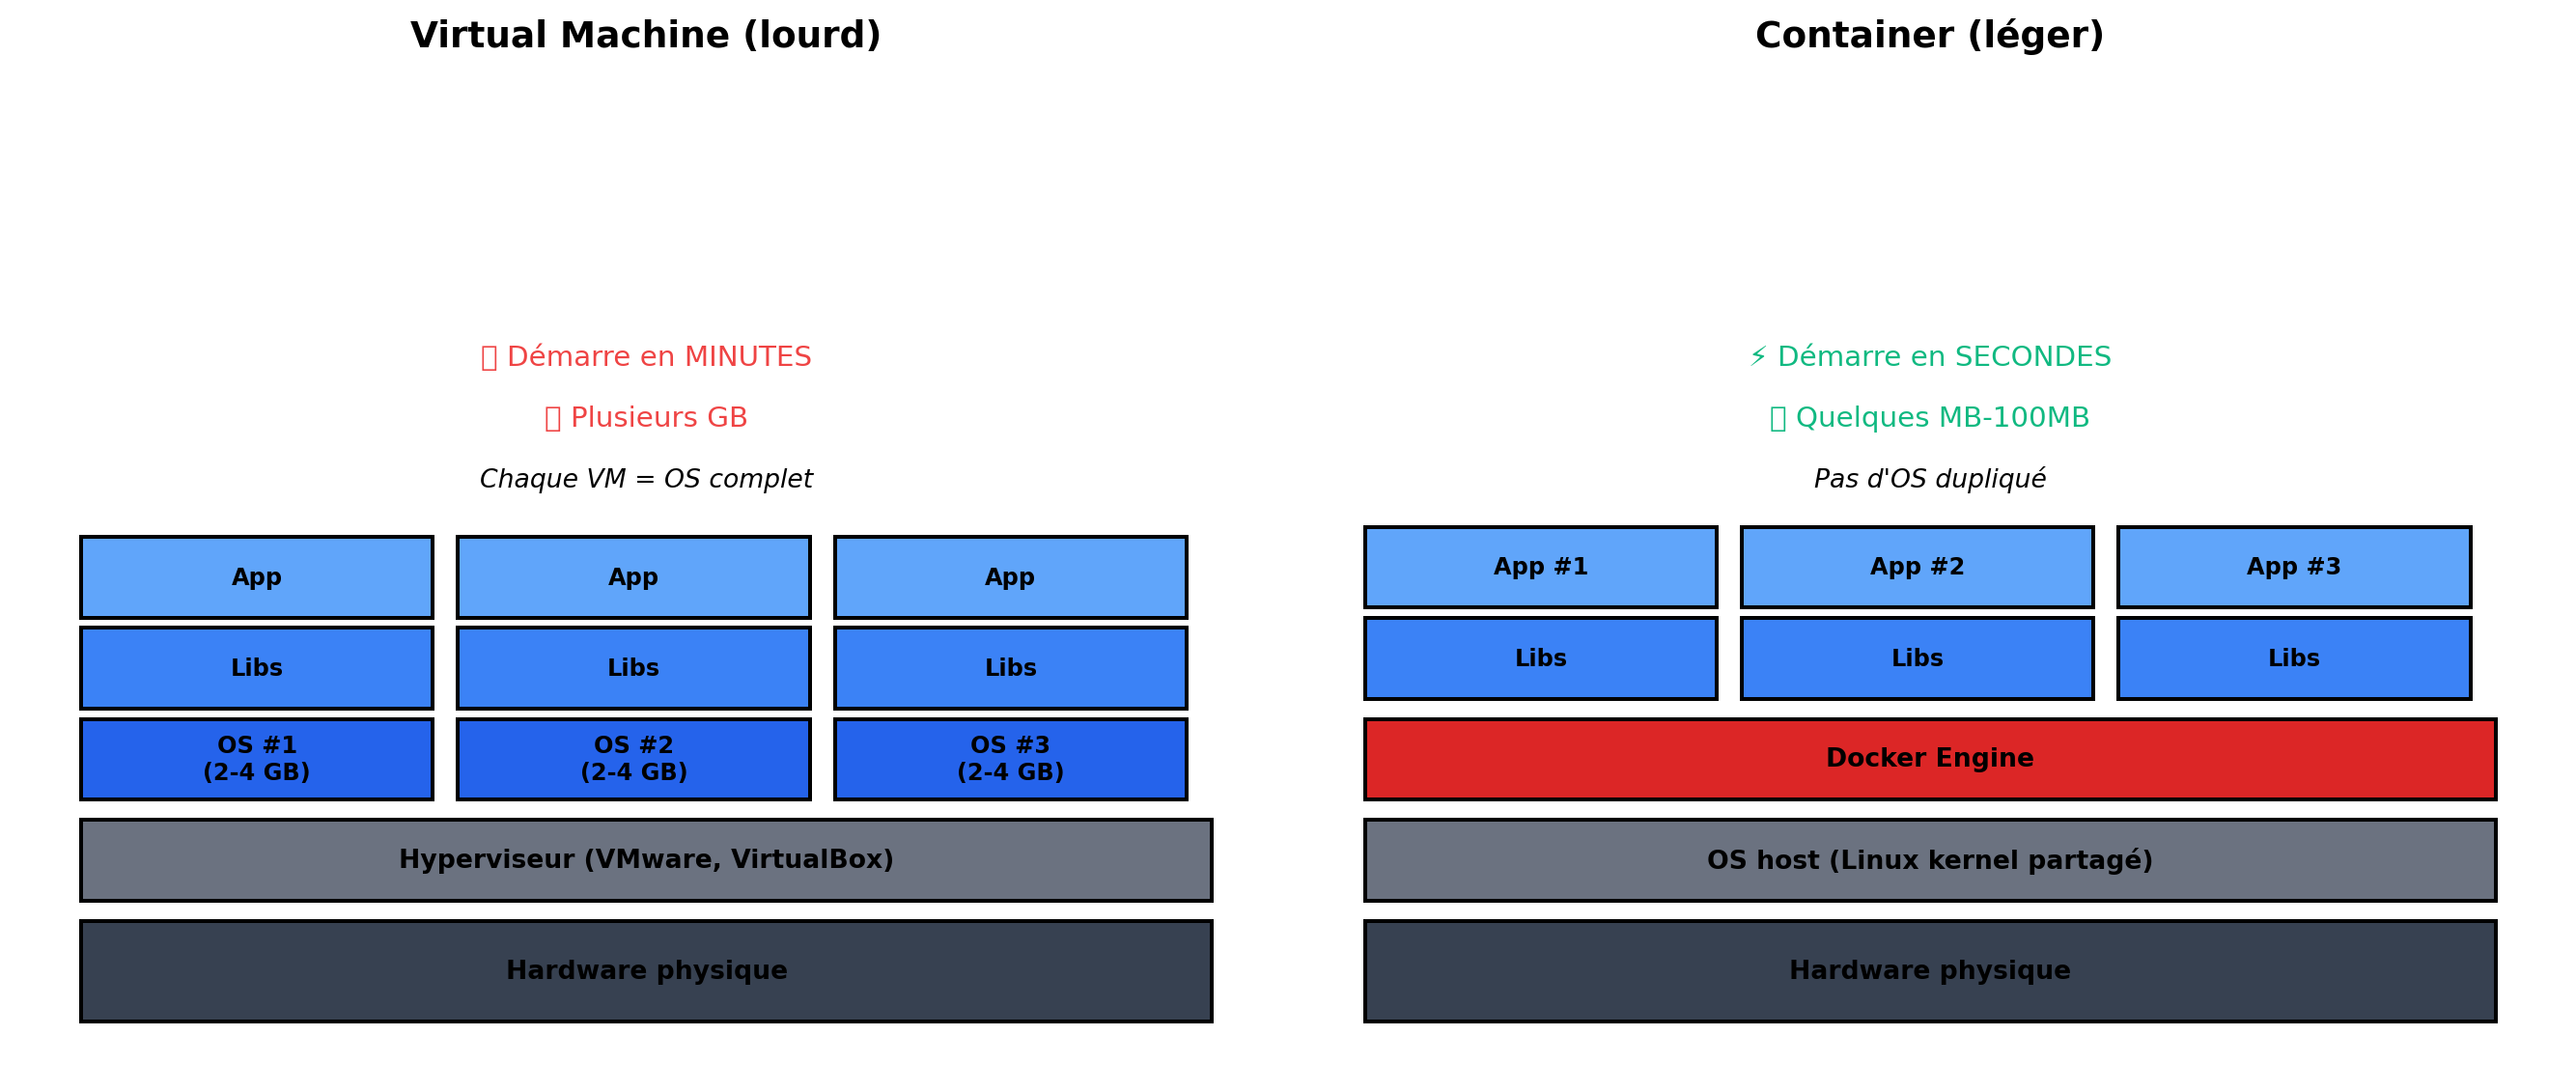

In [3]:
#| label: fig-container-vs-vm
#| fig-cap: 'Container vs VM : la différence d''architecture'

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def boite(ax, x, y, w, h, color, text, fontsize=10):
    ax.add_patch(mpatches.Rectangle((x, y), w, h, facecolor=color,
                                      edgecolor='black', linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
             fontsize=fontsize, fontweight='bold')

# === VM ===
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("Virtual Machine (lourd)", fontsize=14, fontweight='bold')

boite(ax, 0.5, 0.5, 9, 1, "#374151", "Hardware physique")
boite(ax, 0.5, 1.7, 9, 0.8, "#6b7280", "Hyperviseur (VMware, VirtualBox)")
for i, x in enumerate([0.5, 3.5, 6.5]):
    boite(ax, x, 2.7, 2.8, 0.8, "#2563eb", f"OS #{i+1}\n(2-4 GB)", 9)
    boite(ax, x, 3.6, 2.8, 0.8, "#3b82f6", "Libs", 9)
    boite(ax, x, 4.5, 2.8, 0.8, "#60a5fa", "App", 9)

ax.text(5, 7, "🐌 Démarre en MINUTES", ha='center', fontsize=11, color='#ef4444')
ax.text(5, 6.4, "📦 Plusieurs GB", ha='center', fontsize=11, color='#ef4444')
ax.text(5, 5.8, "Chaque VM = OS complet", ha='center', fontsize=10, style='italic')

# === Container ===
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("Container (léger)", fontsize=14, fontweight='bold')

boite(ax, 0.5, 0.5, 9, 1, "#374151", "Hardware physique")
boite(ax, 0.5, 1.7, 9, 0.8, "#6b7280", "OS host (Linux kernel partagé)")
boite(ax, 0.5, 2.7, 9, 0.8, "#dc2626", "Docker Engine")
for i, x in enumerate([0.5, 3.5, 6.5]):
    boite(ax, x, 3.7, 2.8, 0.8, "#3b82f6", "Libs", 9)
    boite(ax, x, 4.6, 2.8, 0.8, "#60a5fa", f"App #{i+1}", 9)

ax.text(5, 7, "⚡ Démarre en SECONDES", ha='center', fontsize=11, color='#10b981')
ax.text(5, 6.4, "📦 Quelques MB-100MB", ha='center', fontsize=11, color='#10b981')
ax.text(5, 5.8, "Pas d'OS dupliqué", ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

In [4]:
DOCKERFILE_BASIQUE = """
# Image de base : Python 3.12 sur Linux léger
FROM python:3.12-slim

# Dossier de travail dans le container
WORKDIR /app

# Copier requirements et installer
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copier le code source
COPY app.py .
COPY models/ ./models/

# Port exposé (info pour Docker)
EXPOSE 8000

# Commande lancée au démarrage
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""
print(DOCKERFILE_BASIQUE)


# Image de base : Python 3.12 sur Linux léger
FROM python:3.12-slim

# Dossier de travail dans le container
WORKDIR /app

# Copier requirements et installer
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copier le code source
COPY app.py .
COPY models/ ./models/

# Port exposé (info pour Docker)
EXPOSE 8000

# Commande lancée au démarrage
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



In [5]:
COMMANDES_DOCKER = {
    "docker build -t monapp:v1 .": "Construire une image",
    "docker run -p 8000:8000 monapp:v1": "Lancer un container",
    "docker ps": "Lister les containers en cours",
    "docker ps -a": "Lister TOUS les containers (même stoppés)",
    "docker images": "Lister les images en local",
    "docker logs <container_id>": "Voir les logs d'un container",
    "docker exec -it <container_id> bash": "Ouvrir un shell DANS le container (debug)",
    "docker stop <container_id>": "Arrêter un container",
    "docker rm <container_id>": "Supprimer un container stoppé",
    "docker rmi <image_id>": "Supprimer une image",
}

for cmd, desc in COMMANDES_DOCKER.items():
    print(f"  {cmd:50s} → {desc}")

  docker build -t monapp:v1 .                        → Construire une image
  docker run -p 8000:8000 monapp:v1                  → Lancer un container
  docker ps                                          → Lister les containers en cours
  docker ps -a                                       → Lister TOUS les containers (même stoppés)
  docker images                                      → Lister les images en local
  docker logs <container_id>                         → Voir les logs d'un container
  docker exec -it <container_id> bash                → Ouvrir un shell DANS le container (debug)
  docker stop <container_id>                         → Arrêter un container
  docker rm <container_id>                           → Supprimer un container stoppé
  docker rmi <image_id>                              → Supprimer une image


In [6]:
DOCKERIGNORE = """
# Git
.git
.gitignore

# Python
__pycache__/
*.pyc
.pytest_cache/
.venv/
venv/

# Logs et data
*.log
data/raw/
*.csv

# Notebooks
.ipynb_checkpoints/

# IDE
.vscode/
.idea/
"""
print(DOCKERIGNORE)


# Git
.git
.gitignore

# Python
__pycache__/
*.pyc
.pytest_cache/
.venv/
venv/

# Logs et data
*.log
data/raw/
*.csv

# Notebooks
.ipynb_checkpoints/

# IDE
.vscode/
.idea/



In [7]:
DOCKERFILE_MULTISTAGE = """
# === Stage 1 : Builder ===
FROM python:3.12 AS builder

WORKDIR /build

# Installer les outils de compilation (gcc...)
RUN apt-get update && apt-get install -y build-essential

COPY requirements.txt .
RUN pip install --user --no-cache-dir -r requirements.txt


# === Stage 2 : Runtime (final) ===
FROM python:3.12-slim

WORKDIR /app

# Récupérer SEULEMENT les libs installées (pas les outils de compilation)
COPY --from=builder /root/.local /root/.local
ENV PATH=/root/.local/bin:$PATH

COPY app.py .
COPY models/ ./models/

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""
print(DOCKERFILE_MULTISTAGE)


# === Stage 1 : Builder ===
FROM python:3.12 AS builder

WORKDIR /build

# Installer les outils de compilation (gcc...)
RUN apt-get update && apt-get install -y build-essential

COPY requirements.txt .
RUN pip install --user --no-cache-dir -r requirements.txt


# === Stage 2 : Runtime (final) ===
FROM python:3.12-slim

WORKDIR /app

# Récupérer SEULEMENT les libs installées (pas les outils de compilation)
COPY --from=builder /root/.local /root/.local
ENV PATH=/root/.local/bin:$PATH

COPY app.py .
COPY models/ ./models/

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



In [8]:
DOCKER_COMPOSE = """
version: '3.9'

services:
  # === Service 1 : ton API ===
  api:
    build: .                       # build depuis le Dockerfile local
    ports:
      - "8000:8000"
    environment:
      - DB_URL=postgresql://user:pass@db:5432/mydb
      - LOG_LEVEL=INFO
    volumes:
      - ./models:/app/models       # modèles partagés depuis l'host
    depends_on:
      - db                         # attend que db soit prête
    restart: unless-stopped

  # === Service 2 : base PostgreSQL ===
  db:
    image: postgres:16-alpine
    environment:
      - POSTGRES_USER=user
      - POSTGRES_PASSWORD=pass
      - POSTGRES_DB=mydb
    volumes:
      - postgres_data:/var/lib/postgresql/data
    ports:
      - "5432:5432"

  # === Service 3 : Redis pour cache ===
  redis:
    image: redis:7-alpine
    ports:
      - "6379:6379"

# Volumes nommés
volumes:
  postgres_data:
"""
print(DOCKER_COMPOSE)


version: '3.9'

services:
  # === Service 1 : ton API ===
  api:
    build: .                       # build depuis le Dockerfile local
    ports:
      - "8000:8000"
    environment:
      - DB_URL=postgresql://user:pass@db:5432/mydb
      - LOG_LEVEL=INFO
    volumes:
      - ./models:/app/models       # modèles partagés depuis l'host
    depends_on:
      - db                         # attend que db soit prête
    restart: unless-stopped

  # === Service 2 : base PostgreSQL ===
  db:
    image: postgres:16-alpine
    environment:
      - POSTGRES_USER=user
      - POSTGRES_PASSWORD=pass
      - POSTGRES_DB=mydb
    volumes:
      - postgres_data:/var/lib/postgresql/data
    ports:
      - "5432:5432"

  # === Service 3 : Redis pour cache ===
  redis:
    image: redis:7-alpine
    ports:
      - "6379:6379"

# Volumes nommés
volumes:
  postgres_data:

